### Student Name: Feliciann Elliot
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assigment #2

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Simple Self-Attention Implementation

In [9]:
tokens = ["Your", "journey", "starts", "with", "one", "step"]

In [10]:
vocab = {tok: i for i, tok in enumerate(tokens)}
input_ids = torch.tensor([vocab[t] for t in tokens])   # shape: (6,)

# 3) Embedding layer
embed_dim = 3
embedding = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_dim)

# 4) Get inputs
inputs = embedding(input_ids)

print("inputs shape:", inputs.shape)
print("inputs:\n", inputs)

inputs shape: torch.Size([6, 3])
inputs:
 tensor([[ 0.1317, -0.4357, -1.1627],
        [-0.4250, -0.6661,  0.5755],
        [-1.4172, -0.6750,  1.5312],
        [ 0.3689,  1.2227, -1.1921],
        [-0.5916,  1.6836,  0.0075],
        [-1.0012, -2.0692,  0.3856]], grad_fn=<EmbeddingBackward0>)


In [11]:
attn_scores = inputs @ inputs.T

print("Unnormalized Attention Scores:\n", attn_scores)

# 3. Calculate Attention Weights
attn_weights = torch.softmax(attn_scores, dim=1)

print("\nNormalized Attention Weights:\n", attn_weights)

# Check that rows sum to 1
print("Row sums:", attn_weights.sum(dim=1))

# 4. Compute Context Vectors (Weighted Values)
context_vectors = attn_weights @ inputs

print("\nContext Vectors:\n", context_vectors)

Unnormalized Attention Scores:
 tensor([[ 1.5591, -0.4348, -1.6728,  0.9019, -0.8202,  0.3214],
        [-0.4348,  0.9555,  1.9330, -1.6572, -0.8657,  2.0257],
        [-1.6728,  1.9330,  4.8084, -3.1735, -0.2865,  3.4059],
        [ 0.9019, -1.6572, -3.1735,  3.0523,  1.8314, -3.3591],
        [-0.8202, -0.8657, -0.2865,  1.8314,  3.1845, -2.8885],
        [ 0.3214,  2.0257,  3.4059, -3.3591, -2.8885,  5.4326]],
       grad_fn=<MmBackward0>)

Normalized Attention Weights:
 tensor([[4.8155e-01, 6.5570e-02, 1.9014e-02, 2.4958e-01, 4.4599e-02, 1.3968e-01],
        [3.5279e-02, 1.4168e-01, 3.7658e-01, 1.0390e-02, 2.2930e-02, 4.1314e-01],
        [1.1691e-03, 4.3037e-02, 7.6314e-01, 2.6069e-04, 4.6762e-03, 1.8772e-01],
        [8.1765e-02, 6.3266e-03, 1.3889e-03, 7.0223e-01, 2.0713e-01, 1.1536e-03],
        [1.3733e-02, 1.3123e-02, 2.3417e-02, 1.9468e-01, 7.5331e-01, 1.7359e-03],
        [5.1471e-03, 2.8294e-02, 1.1250e-01, 1.2975e-04, 2.0774e-04, 8.5372e-01]],
       grad_fn=<SoftmaxBackw

In [12]:
def plot_attention_weights(weights, tokens):
    plt.figure(figsize=(8, 6))
    sns.heatmap(weights.detach(), annot=True, cmap="viridis",
                xticklabels=tokens, yticklabels=tokens)
    plt.xlabel("Keys (Attended to)")
    plt.ylabel("Queries (Focusing)")
    plt.title("Self-Attention Weights (Non-Trainable)")
    plt.show()

# Token labels for the sample text
tokens = ["Your", "journey", "starts", "with", "one", "step"]

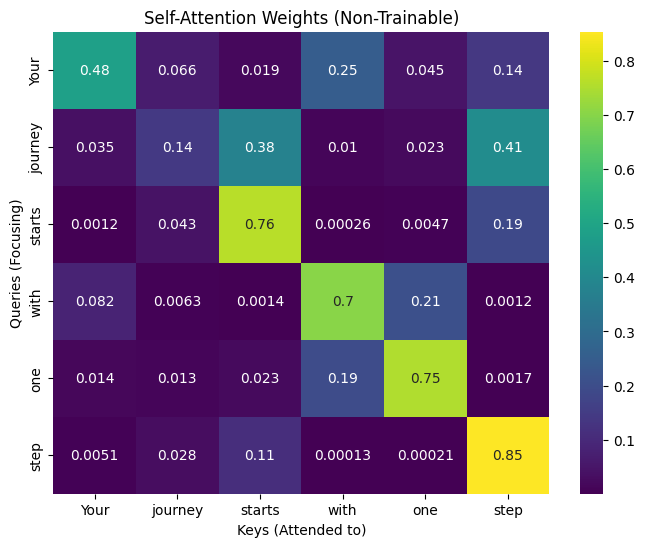

In [13]:
plot_attention_weights(attn_weights, tokens)

### Scaled Dot-Product Attention Implementation

In [14]:
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = k.shape[-1]

    # 1. Attention Scores (Unnormalized)
    attn_scores = q @ k.transpose(-2, -1)

    # 2. Scaling (Section 3.4)
    attn_scores = attn_scores / (d_k ** 0.5)

    # 3. Causal Masking (Section 3.5)
    if mask is not None:

        # We mask with -inf so Softmax forces these to 0
        attn_scores = attn_scores.masked_fill(~mask, float('-inf'))

    # 4. Attention Weights
    attn_weights = torch.softmax(attn_scores, dim=-1)

    # 5. Weighted Values
    output = attn_weights @ v

    return output, attn_weights

In [15]:
context_length = inputs.shape[0]
#mask = torch.tril(torch.ones(context_length, context_length))
mask = torch.tril(torch.ones(context_length, context_length, device=inputs.device)).bool()


print("Causal Mask (1 = keep, 0 = mask):\n", mask)

# Compute Attention (Using inputs as Q, K, V for now)
context_vecs, weights = scaled_dot_product_attention(inputs, inputs, inputs, mask)

print("\nMasked Attention Weights (Rows sum to 1):\n", weights)
print("\nContext Vectors (Causal):\n", context_vecs)

Causal Mask (1 = keep, 0 = mask):
 tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True]])

Masked Attention Weights (Rows sum to 1):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3095, 0.6905, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0195, 0.1566, 0.8238, 0.0000, 0.0000, 0.0000],
        [0.2090, 0.0477, 0.0199, 0.7234, 0.0000, 0.0000],
        [0.0554, 0.0540, 0.0754, 0.2560, 0.5592, 0.0000],
        [0.0345, 0.0922, 0.2046, 0.0041, 0.0054, 0.6592]],
       grad_fn=<SoftmaxBackward0>)

Context Vectors (Causal):
 tensor([[ 0.1317, -0.4357, -1.1627],
        [-0.2528, -0.5948,  0.0376],
        [-1.2315, -0.6689,  1.3289],
        [ 0.2460,  0.7482, -1.0475],
        [-0.3588,  1.1436, -0.2190],
        [-0

In [16]:
def plot_causal_attention(weights, tokens):
    plt.figure(figsize=(8, 6))
    sns.heatmap(weights.detach(), annot=True, cmap="viridis",
                xticklabels=tokens, yticklabels=tokens)
    plt.xlabel("Keys (Attended to)")
    plt.ylabel("Queries (Focusing)")
    plt.title("Causal Self-Attention (Scaled & Masked)")
    plt.show()

tokens = ["Your", "journey", "starts", "with", "one", "step"]

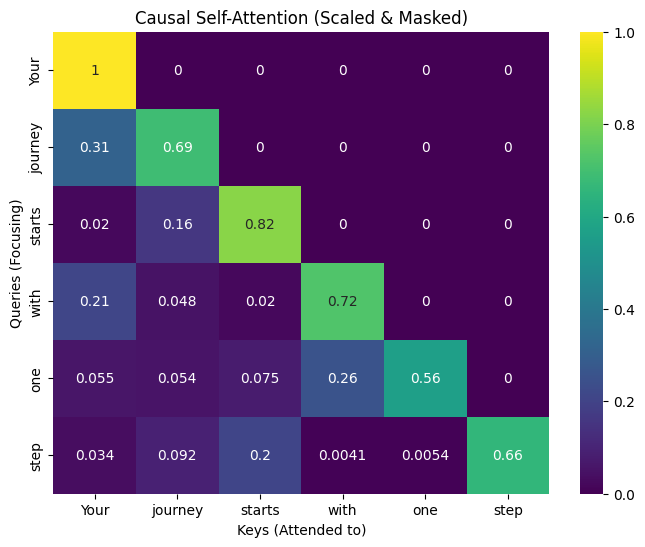

In [17]:
plot_causal_attention(weights, tokens)

In [18]:
#Should be 0 or appromately
print(weights.triu(1).max())

tensor(0., grad_fn=<MaxBackward1>)


In [19]:
#Should be 0 as well
print(weights.triu(1).sum())

tensor(0., grad_fn=<SumBackward0>)


### Trainable Attention Implementation

In [20]:
class TrainableSelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()

        # Initialize W_q, W_k, W_v weight matrices
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x, mask=None):
        # 1. Project inputs to Queries, Keys, and Values
        # Shape: (Batch, Seq_Len, d_out) or (Seq_Len, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 2. Calculate Attention Scores (Scaled Dot-Product)
        attn_scores = queries @ keys.transpose(-2, -1)

        # Scale by sqrt(d_k)
        d_k = keys.shape[-1]
        attn_scores = attn_scores / (d_k ** 0.5)

        if mask is not None:
          attn_scores = attn_scores.masked_fill(~mask, float('-inf'))

        # 3. Apply Softmax to get weights
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # 4. Weighted Sum of Values
        context_vec = attn_weights @ values
        return context_vec, attn_weights

In [21]:
# Initialize dimensions
d_in = 3  # Input embedding size
d_out = 2 # Output embedding size

torch.manual_seed(123)
sa_trainable = TrainableSelfAttention(d_in, d_out)

# Forward pass
context_vectors, weights = sa_trainable(inputs)

In [22]:
print("Context Vectors (Trainable):\n", context_vectors)
print("\nOutput Shape:", context_vectors.shape)

Context Vectors (Trainable):
 tensor([[0.3238, 0.1709],
        [0.3204, 0.1908],
        [0.3307, 0.2111],
        [0.2431, 0.0389],
        [0.2284, 0.0214],
        [0.3968, 0.3071]], grad_fn=<MmBackward0>)

Output Shape: torch.Size([6, 2])


In [23]:
# Check the parameter shapes
for name, param in sa_trainable.named_parameters():
    print(f"{name}: {param.shape}")

W_query.weight: torch.Size([2, 3])
W_key.weight: torch.Size([2, 3])
W_value.weight: torch.Size([2, 3])


### Multihead Attention Implementation

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Dimension of each head

        # Linear projections for Q, K, V
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Output projection to mix head outputs
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Causal mask buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, device=inputs.device),
                       diagonal=1).bool()
        )

    def forward(self, x):
      b, num_tokens, _ = x.shape

      keys = self.W_key(x)
      queries = self.W_query(x)
      values = self.W_value(x)

      keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
      queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
      values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

      attn_scores = queries @ keys.transpose(2, 3)
      attn_scores = attn_scores / (self.head_dim ** 0.5)

      mask_bool = self.mask[:num_tokens, :num_tokens]  # (T,T), broadcasts over (b,h)
      attn_scores = attn_scores.masked_fill(mask_bool, float("-inf"))

      attn_weights = torch.softmax(attn_scores, dim=-1)
      attn_weights = self.dropout(attn_weights)

      context = (attn_weights @ values).transpose(1, 2).contiguous()
      context = context.view(b, num_tokens, self.d_out)

      out = self.out_proj(context)
      return out

In [25]:
batch = torch.stack((inputs, inputs), dim=0)

# Settings
d_in = 3
d_out = 4
num_heads = 2
context_length = 10

torch.manual_seed(123)
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)

# Forward pass
output = mha(batch)

print("Input Shape:", batch.shape)
print("Output Shape:", output.shape)
print("\nMulti-Head Output (First sequence in batch):\n", output[0])

Input Shape: torch.Size([2, 6, 3])
Output Shape: torch.Size([2, 6, 4])

Multi-Head Output (First sequence in batch):
 tensor([[ 0.0915,  0.0228, -0.0443, -0.3094],
        [ 0.2507,  0.1316, -0.0688, -0.6290],
        [ 0.3917,  0.2224, -0.0850, -0.8877],
        [ 0.0415,  0.0544, -0.0548, -0.2919],
        [-0.0070,  0.1064, -0.0509, -0.2295],
        [ 0.3605,  0.3276, -0.0752, -0.8416]], grad_fn=<SelectBackward0>)


### Exercise 3.1: Implement Attention with Different Numbers of Heads

In [28]:
import time

In [29]:
torch.manual_seed(123)

d_in = 8
d_out = 8
context_length = 10
dropout = 0.0
batch = torch.randn(2, 5, d_in)

head_configs = [1, 2, 4, 8]
results = {}
stats = {}
times = {}

In [30]:
for num_heads in head_configs:
    print(f"Testing with {num_heads} heads...")

    torch.manual_seed(123)
    mha = MultiHeadAttention(d_in, d_out, context_length, dropout, num_heads)

    t0 = time.perf_counter()
    out = mha(batch)
    t1 = time.perf_counter()

    results[num_heads] = out.detach()
    times[num_heads] = (t1 - t0) * 1000  # ms

    # Output stats
    stats[num_heads] = {
        "head_dim": d_out // num_heads,
        "shape": tuple(out.shape),
        "mean": out.mean().item(),
        "std": out.std().item(),
        "min": out.min().item(),
        "max": out.max().item(),
        "l2_norm": out.norm().item(),
    }

    print(f"  Head Dimension: {stats[num_heads]['head_dim']}")
    print(f"  Output Shape:   {stats[num_heads]['shape']}")
    print(f"  mean/std:       {stats[num_heads]['mean']:.4f} / {stats[num_heads]['std']:.4f}")
    print(f"  min/max:        {stats[num_heads]['min']:.4f} / {stats[num_heads]['max']:.4f}")
    print(f"  L2 norm:        {stats[num_heads]['l2_norm']:.4f}")
    print(f"  time:           {times[num_heads]:.3f} ms")
    print("-" * 50)

Testing with 1 heads...
  Head Dimension: 8
  Output Shape:   (2, 5, 8)
  mean/std:       0.0650 / 0.2711
  min/max:        -0.6612 / 0.5769
  L2 norm:        2.4787
  time:           0.621 ms
--------------------------------------------------
Testing with 2 heads...
  Head Dimension: 4
  Output Shape:   (2, 5, 8)
  mean/std:       0.0657 / 0.2695
  min/max:        -0.6522 / 0.5698
  L2 norm:        2.4663
  time:           0.532 ms
--------------------------------------------------
Testing with 4 heads...
  Head Dimension: 2
  Output Shape:   (2, 5, 8)
  mean/std:       0.0621 / 0.2687
  min/max:        -0.6286 / 0.5628
  L2 norm:        2.4517
  time:           0.385 ms
--------------------------------------------------
Testing with 8 heads...
  Head Dimension: 1
  Output Shape:   (2, 5, 8)
  mean/std:       0.0621 / 0.2657
  min/max:        -0.6321 / 0.5648
  L2 norm:        2.4257
  time:           0.459 ms
--------------------------------------------------


In [31]:
base = results[1]
print("\nComparison vs 1 head baseline")
for h in [2, 4, 8]:
    mse = torch.mean((results[h] - base) ** 2).item()
    cos = torch.nn.functional.cosine_similarity(
        results[h].flatten(), base.flatten(), dim=0
    ).item()
    print(f"{h} heads -> MSE: {mse:.6f}, cosine sim: {cos:.6f}")


Comparison vs 1 head baseline
2 heads -> MSE: 0.000633, cosine sim: 0.995871
4 heads -> MSE: 0.000853, cosine sim: 0.994446
8 heads -> MSE: 0.001179, cosine sim: 0.992392


### Exercise 3.2: Visualize attention patterns for different types of text (narrative, code, poetry)

In [34]:
def visualize_text_attention(text_type, tokens, inputs, mha_model):

    with torch.no_grad():
        b, num_tokens, d_in = inputs.shape

        # 1. Project and Split
        keys = mha_model.W_key(inputs)
        queries = mha_model.W_query(inputs)

        # Reshape for 1 head for simple visualization
        keys = keys.view(b, num_tokens, 1, d_in)
        queries = queries.view(b, num_tokens, 1, d_in)

        # 2. Compute Scores
        # (b, 1, tokens, dim) @ (b, 1, dim, tokens)
        attn_scores = queries.transpose(1, 2) @ keys.transpose(1, 2).transpose(2, 3)

        # Scale
        attn_scores = attn_scores / (d_in**0.5)

        # Mask (Causal)
        mask = torch.triu(torch.ones(num_tokens, num_tokens), diagonal=1)
        attn_scores.masked_fill_(mask.bool(), -torch.inf)

        # Softmax
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # Remove batch/head dims for plotting: (tokens, tokens)
        weights_2d = attn_weights[0, 0]

        plt.figure(figsize=(8, 6))
        sns.heatmap(weights_2d, annot=True, cmap="Reds", xticklabels=tokens, yticklabels=tokens)
        plt.title(f"Attention Pattern: {text_type}")
        plt.xlabel("Keys (Attended to)")
        plt.ylabel("Queries (Focusing)")
        plt.show()

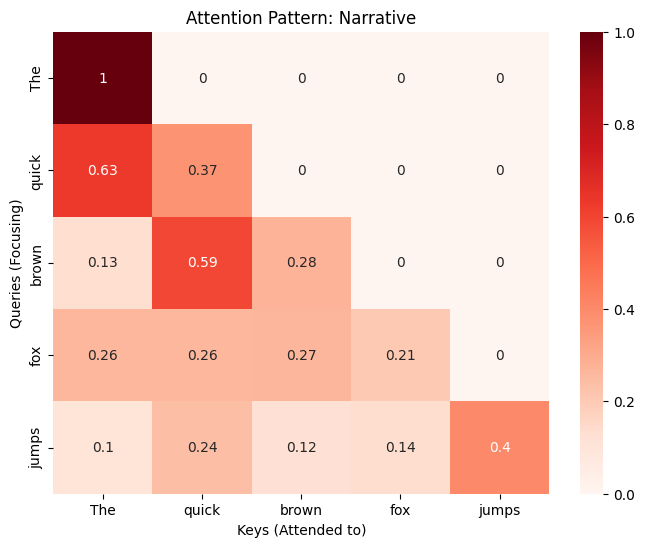

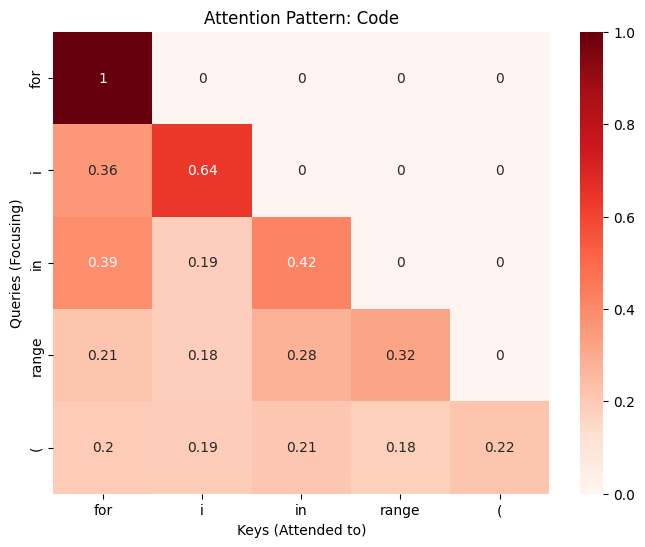

In [36]:
tokens_narrative = ["The", "quick", "brown", "fox", "jumps"]
inputs_narrative = torch.randn(1, 5, 8) # Dummy embeddings

# 2. Code
tokens_code = ["for", "i", "in", "range", "("]
inputs_code = torch.randn(1, 5, 8)

# Initialize a model
mha_viz = MultiHeadAttention(d_in=8, d_out=8, context_length=10, dropout=0.0, num_heads=1)

# Generate Plots
visualize_text_attention("Narrative", tokens_narrative, inputs_narrative, mha_viz)

visualize_text_attention("Code", tokens_code, inputs_code, mha_viz)